In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Combined_Dataset.csv')
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,48833,1,1,53,114,53,53,53.00,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,2006,100,1,1,2,6,2,2,2.00,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
2,9040,11,1,1,0,6,0,0,0.00,0.000000,...,40,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
3,80,13087865,2,0,712,0,356,356,356.00,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS_Attack
4,80,100812634,8,6,330,11595,324,0,41.25,114.267543,...,20,996.0,0.0,996,996,101000000.0,0.0,101000000,101000000,DoS Hulk


## Encoding the target column

In [3]:
df['Label'].value_counts()

Label
BENIGN         33333
PortScan       33333
DoS Hulk       33333
DDoS           33333
DoS_Attack     20899
Brute_Force     9152
Name: count, dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Label'] = encoder.fit_transform(df['Label'])

In [5]:
df['Label'].value_counts()

Label
0    33333
5    33333
3    33333
2    33333
4    20899
1     9152
Name: count, dtype: int64

## Splitting the dataset

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((130706, 78), (130706,), (32677, 78), (32677,))

## Removing feature based on Correlation value

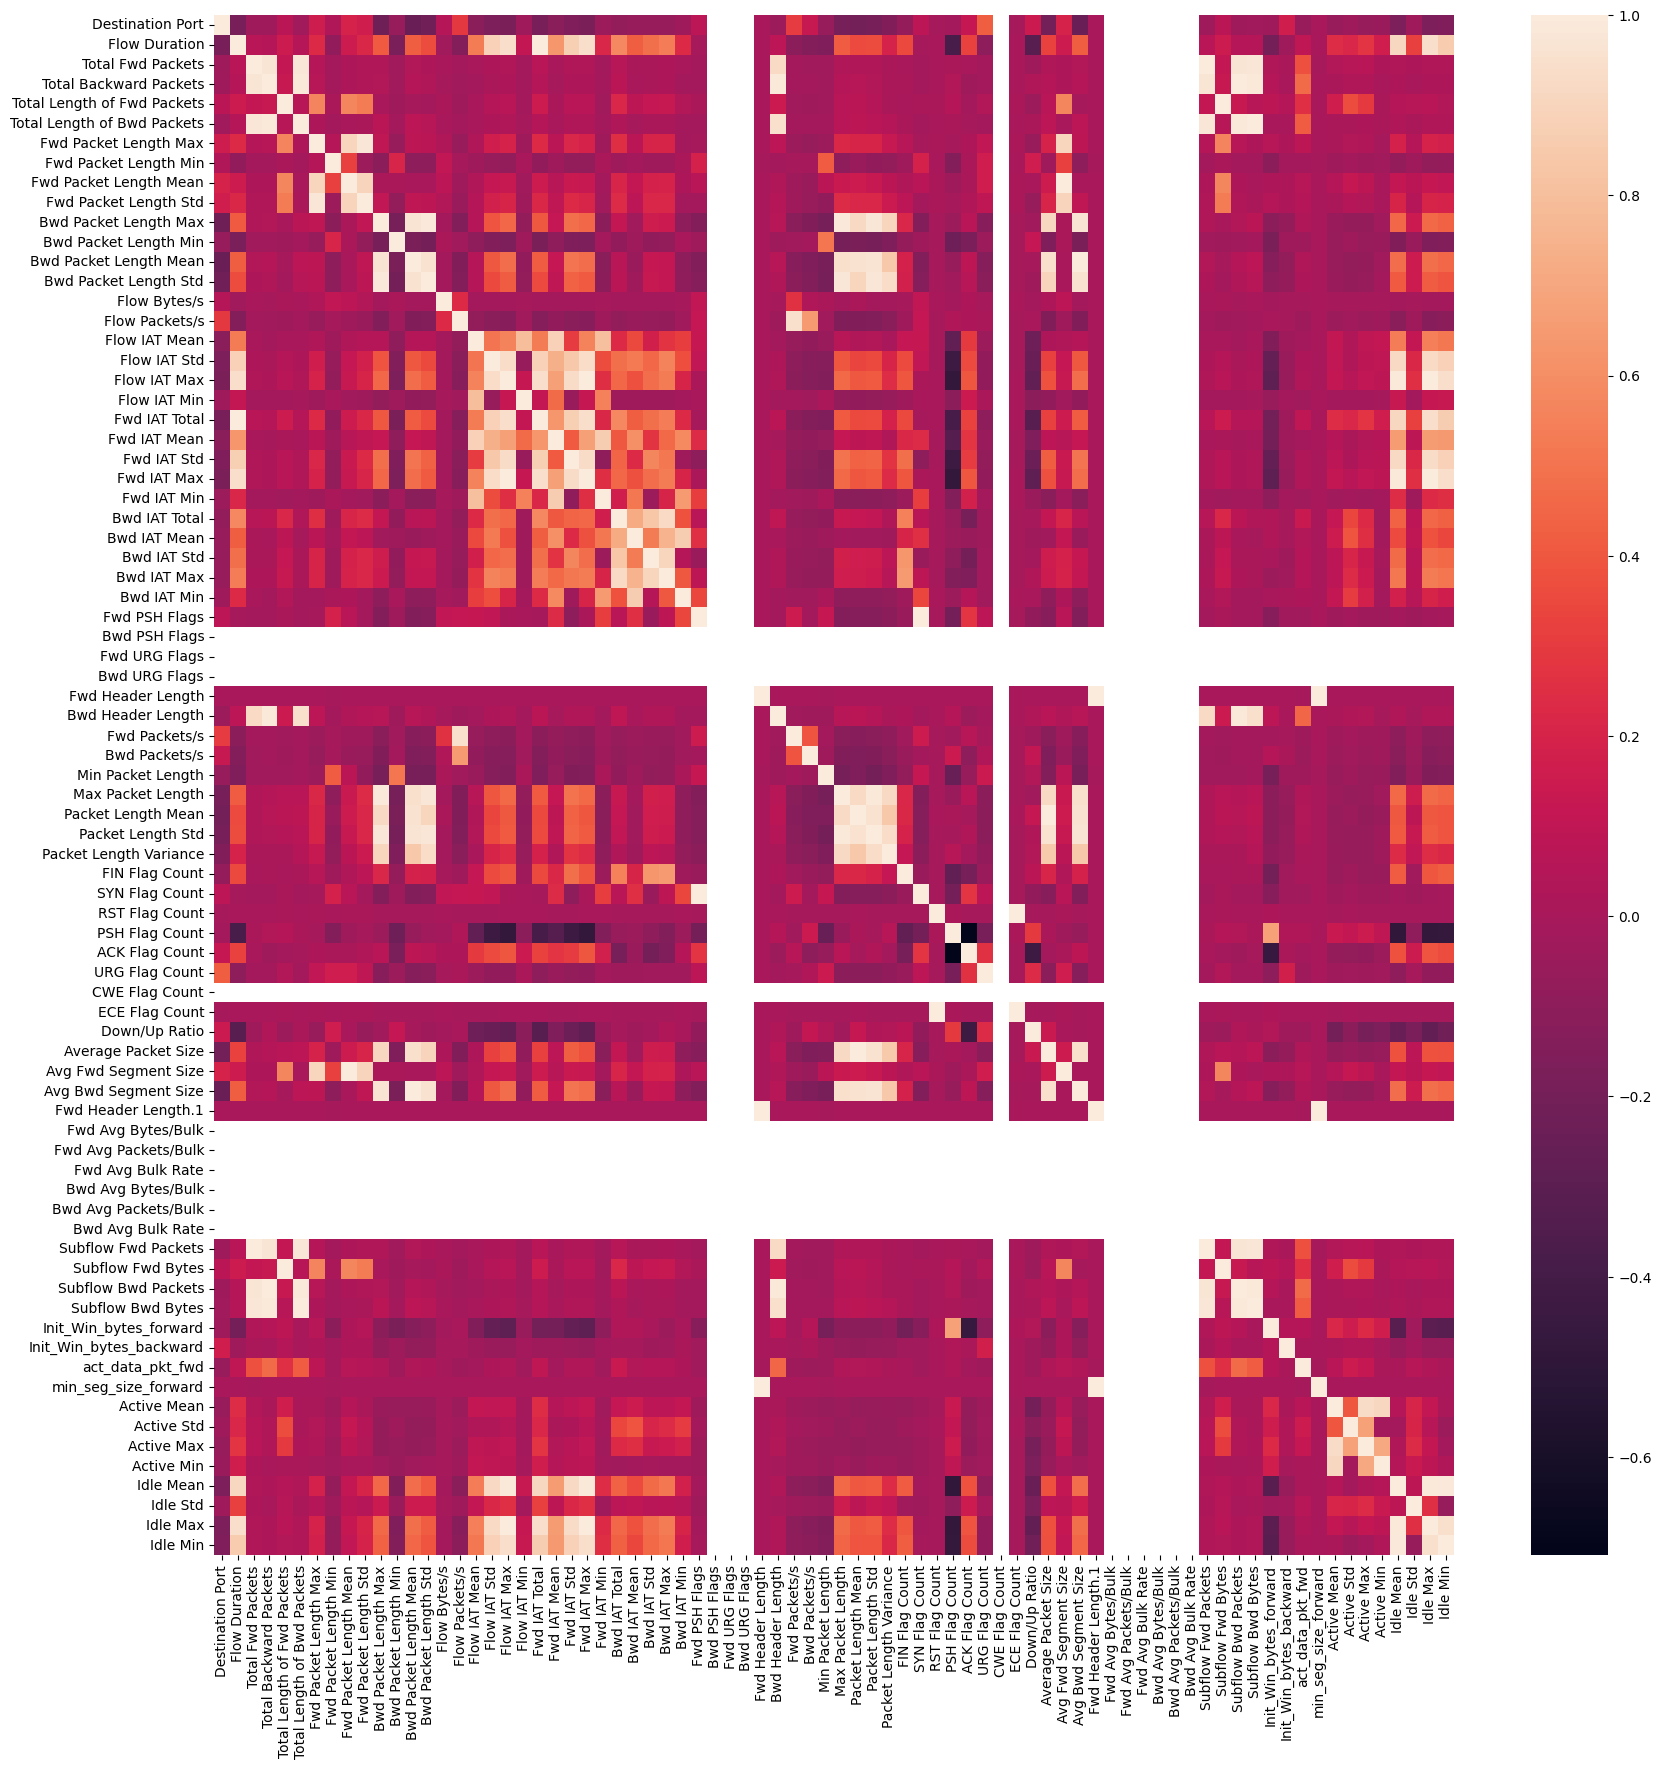

In [9]:
plt.figure(figsize= (20, 20))

corr = X_train.corr()
sns.heatmap(corr, annot= False)
plt.show()

In [10]:
drop_columns = [
    'Subflow Fwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Packets',
    'Subflow Bwd Bytes',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',

    'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk',
    'Bwd Avg Bulk Rate',

    'Bwd PSH Flags',
    'Fwd URG Flags',
    'Bwd URG Flags',
    'CWE Flag Count'
]

In [11]:
X_train = X_train.drop(columns= drop_columns)
X_test = X_test.drop(columns= drop_columns)

In [12]:
def correlation(dataset, threshold):
    col_corr = set()  
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

In [13]:
correlated_columns = correlation(X_train, 0.90)

In [14]:
X_train = X_train.drop(columns= correlated_columns)
X_test = X_test.drop(columns= correlated_columns)

In [15]:
X_train.shape, X_test.shape

((130706, 35), (32677, 35))

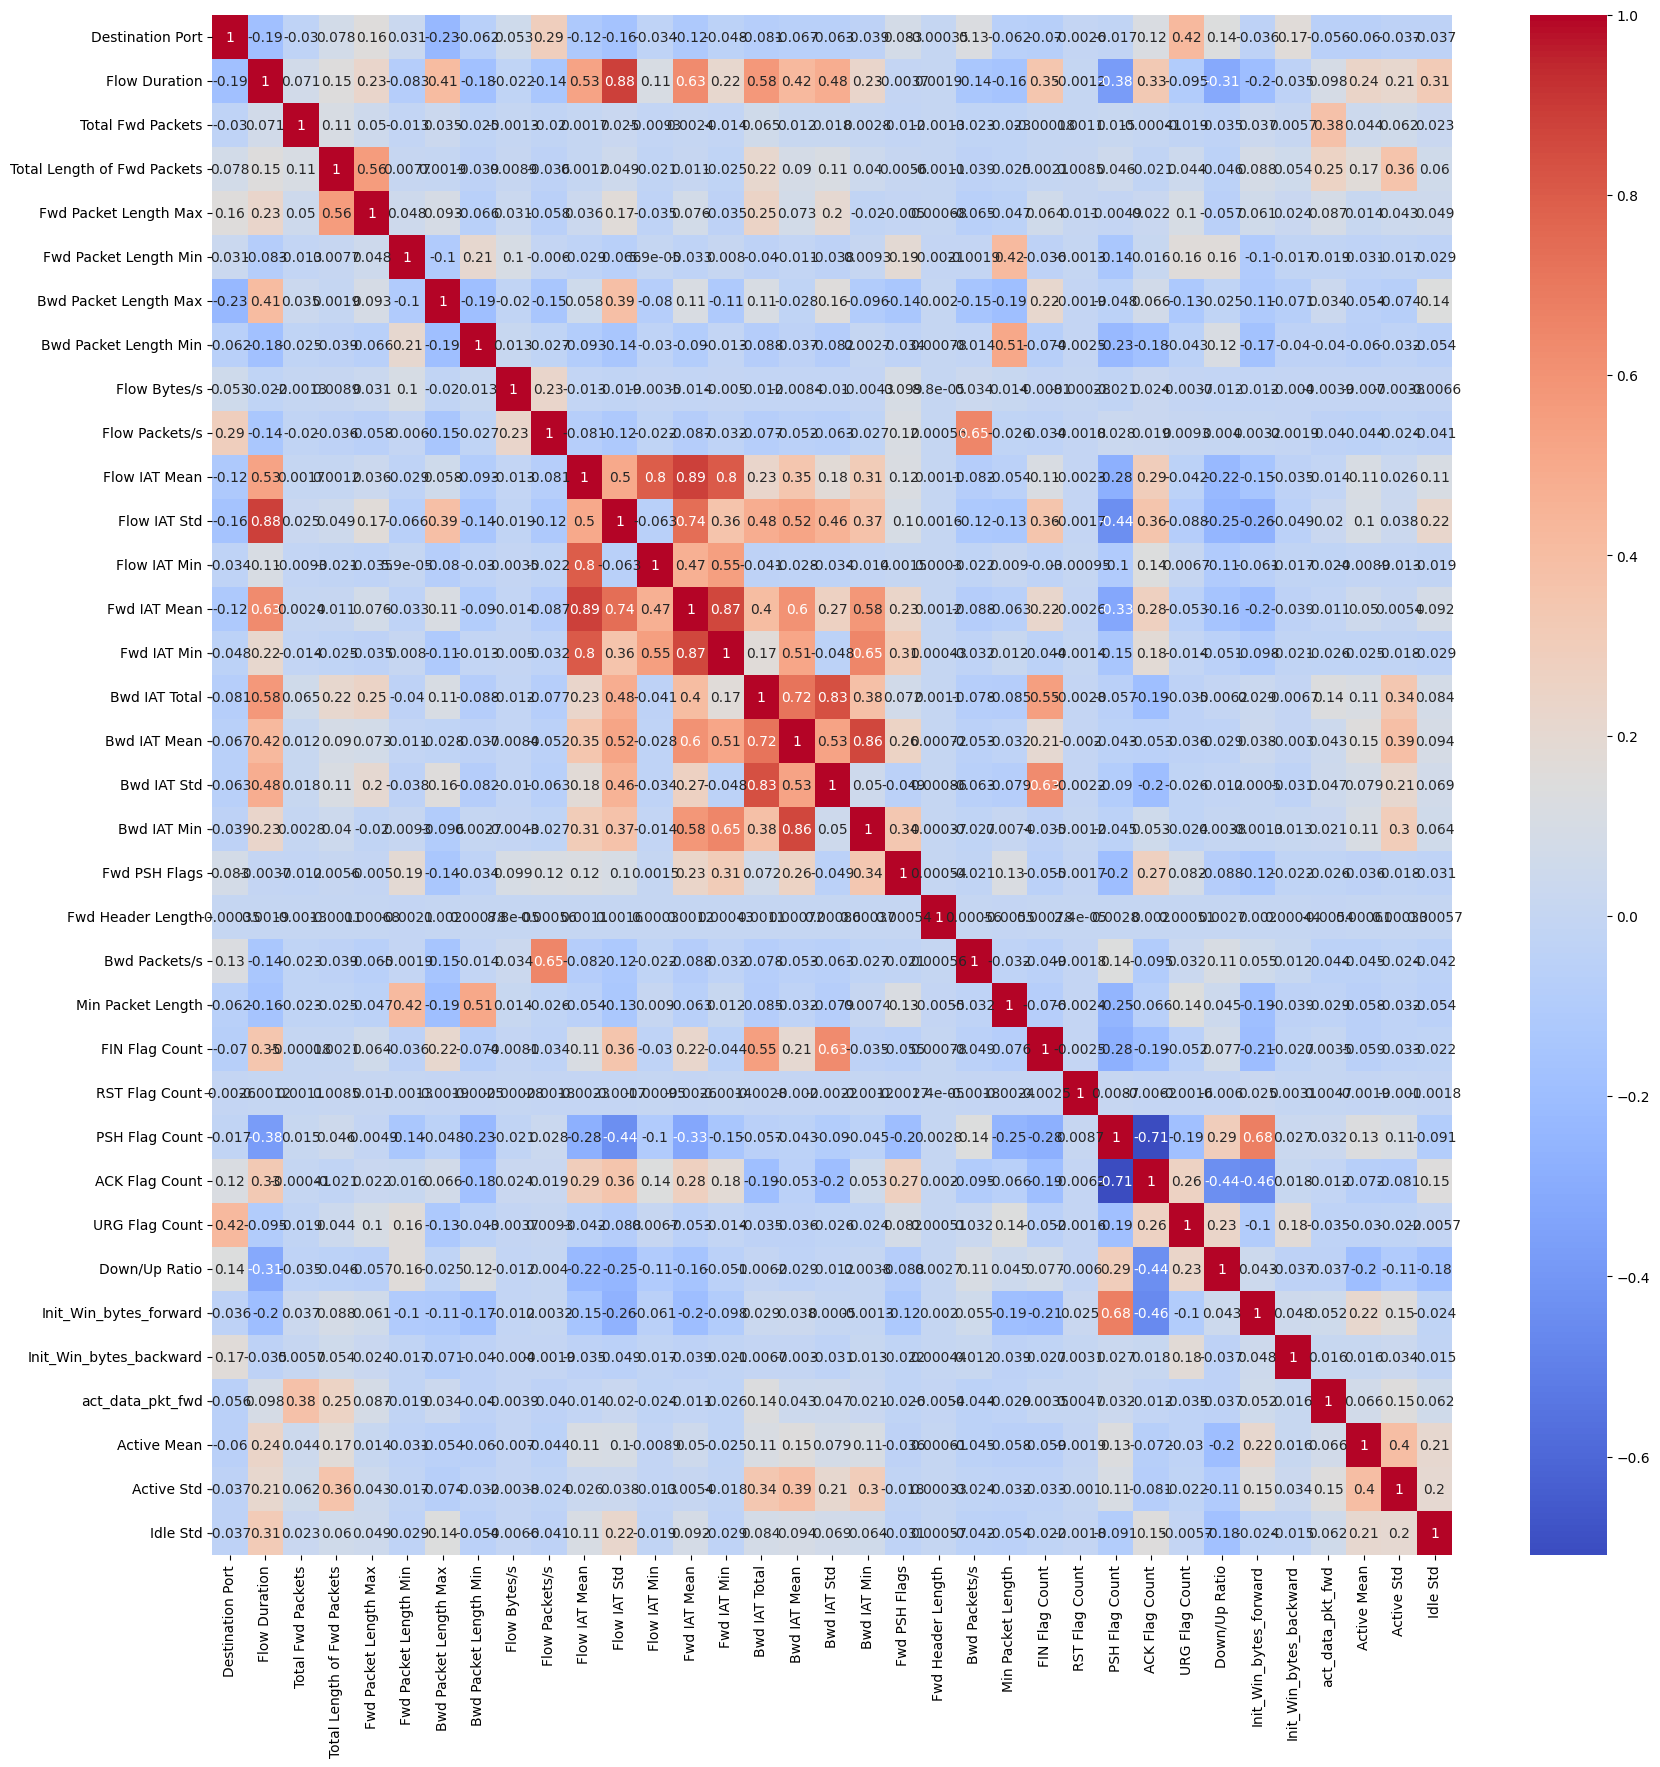

In [16]:
plt.figure(figsize= (20, 20))

corr = X_train.corr()
sns.heatmap(corr, annot= True, cmap= 'coolwarm')
plt.show()

## Handling Outliers

In [17]:
for col in X_train.columns:
    print(col)
    print(X_train[col].describe())
    print()

Destination Port
count    130706.000000
mean       3870.707795
std       11956.711094
min           0.000000
25%          80.000000
50%          80.000000
75%         443.000000
max       65502.000000
Name: Destination Port, dtype: float64

Flow Duration
count    1.307060e+05
mean     2.756754e+07
std      4.065037e+07
min     -1.000000e+00
25%      1.960000e+02
50%      1.616989e+06
75%      6.753897e+07
max      1.199994e+08
Name: Flow Duration, dtype: float64

Total Fwd Packets
count    130706.000000
mean          5.256224
std          36.968779
min           1.000000
25%           1.000000
50%           3.000000
75%           7.000000
max       11930.000000
Name: Total Fwd Packets, dtype: float64

Total Length of Fwd Packets
count    130706.000000
mean        346.165126
std        1759.761200
min           0.000000
25%           2.000000
50%          30.000000
75%         344.000000
max      309463.000000
Name: Total Length of Fwd Packets, dtype: float64

Fwd Packet Length Max
coun

C:\Users\RASHMI TIWARI\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\RASHMI TIWARI\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.307060e+05
mean              inf
std               NaN
min     -2.000000e+06
25%      1.780659e-01
50%      4.947614e+00
75%      1.818182e+04
max               inf
Name: Flow Packets/s, dtype: float64

Flow IAT Mean
count    1.307060e+05
mean     3.462278e+06
std      8.607798e+06
min     -1.000000e+00
25%      9.500000e+01
50%      2.215997e+05
75%      6.063774e+06
max      1.200000e+08
Name: Flow IAT Mean, dtype: float64

Flow IAT Std
count    1.307060e+05
mean     7.340125e+06
std      1.227264e+07
min      0.000000e+00
25%      0.000000e+00
50%      4.064151e+05
75%      1.190000e+07
max      8.470000e+07
Name: Flow IAT Std, dtype: float64

Flow IAT Min
count    1.307060e+05
mean     7.761208e+05
std      7.117482e+06
min     -1.300000e+01
25%      3.000000e+00
50%      1.100000e+01
75%      5.700000e+01
max      1.200000e+08
Name: Flow IAT Min, dtype: float64

Fwd IAT Mean
count    1.307060e+05
mean     6.064100e+06
std      1.403463e+07
min      0.000000e+00
25%     

In [21]:
def remove_outlier(X_train, X_test, columns):
    iqr_bounds = {}
    for col in columns:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + 1.5*IQR
        lower_limit = Q1 - 1.5*IQR

        iqr_bounds[col] = (lower_limit, upper_limit)

        X_train[col] = X_train[col].clip(lower_limit, upper_limit)
        X_test[col] = X_test[col].clip(lower_limit, upper_limit)

    return iqr_bounds

In [22]:
iqr_bounds = remove_outlier(X_train, X_test, X_train.columns)

In [23]:
iqr_bounds

{'Destination Port': (np.float64(-464.5), np.float64(987.5)),
 'Flow Duration': (np.float64(-101307969.875), np.float64(168847139.125)),
 'Total Fwd Packets': (np.float64(-8.0), np.float64(16.0)),
 'Total Length of Fwd Packets': (np.float64(-511.0), np.float64(857.0)),
 'Fwd Packet Length Max': (np.float64(-478.0), np.float64(802.0)),
 'Fwd Packet Length Min': (np.float64(-3.0), np.float64(5.0)),
 'Bwd Packet Length Max': (np.float64(-8673.0), np.float64(14471.0)),
 'Bwd Packet Length Min': (np.float64(-9.0), np.float64(15.0)),
 'Flow Bytes/s': (np.float64(-136069.04596468748),
  np.float64(227095.9730348125)),
 'Flow Packets/s': (np.float64(-27272.282105233746),
  np.float64(45454.278351140245)),
 'Flow IAT Mean': (np.float64(-9095422.977625001),
  np.float64(15159291.629375001)),
 'Flow IAT Std': (np.float64(-17850000.0), np.float64(29750000.0)),
 'Flow IAT Min': (np.float64(-78.0), np.float64(138.0)),
 'Fwd IAT Mean': (np.float64(-15150000.0), np.float64(25250000.0)),
 'Fwd IAT Min'

In [24]:
feature_names = X_train.columns.tolist()

## Scaling the data

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Building ANN Model

In [26]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [27]:
model = Sequential()

model.add(Dense(35, activation= 'relu', input_shape=(X_train.shape[1],)))

model.add(Dense(70, activation= 'relu'))
model.add(Dropout(0.3))

model.add(Dense(140, activation= 'relu'))
model.add(Dropout(0.3))

model.add(Dense(70, activation= 'relu'))
model.add(Dropout(0.3))

model.add(Dense(35, activation= 'relu'))
model.add(Dropout(0.3))

model.add(Dense(6, activation='softmax'))

C:\Users\RASHMI TIWARI\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 35)                  │           1,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 70)                  │           2,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 70)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 140)                 │           9,940 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 140)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 70)                  │           9,870 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 70)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 35)                  │           2,485 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 35)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             216 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,291 (102.70 KB)

 Trainable params: 26,291 (102.70 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'])

In [30]:
history = model.fit(X_train, y_train, epochs= 100, batch_size= 512, verbose= 1, validation_split= 0.2)

Epoch 1/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8426 - loss: 0.4613 - val_accuracy: 0.9847 - val_loss: 0.0485
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9837 - loss: 0.0633 - val_accuracy: 0.9919 - val_loss: 0.0287
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9899 - loss: 0.0417 - val_accuracy: 0.9935 - val_loss: 0.0231
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9917 - loss: 0.0321 - val_accuracy: 0.9948 - val_loss: 0.0189
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9929 - loss: 0.0285 - val_accuracy: 0.9950 - val_loss: 0.0174
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9939 - loss: 0.0237 - val_accuracy: 0.9959 - val_loss: 0.0159
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9944 - loss: 0.0217 - val_accuracy: 0.9958 - val_loss: 0.0153
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9949 - loss: 0.0195 - 

In [31]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

1022/1022 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00      6667
 Brute_Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00      6666
    DoS Hulk       0.99      1.00      1.00      6667
  DoS_Attack       1.00      0.99      1.00      4180
    PortScan       1.00      1.00      1.00      6667

    accuracy                           1.00     32677
   macro avg       1.00      1.00      1.00     32677
weighted avg       1.00      1.00      1.00     32677



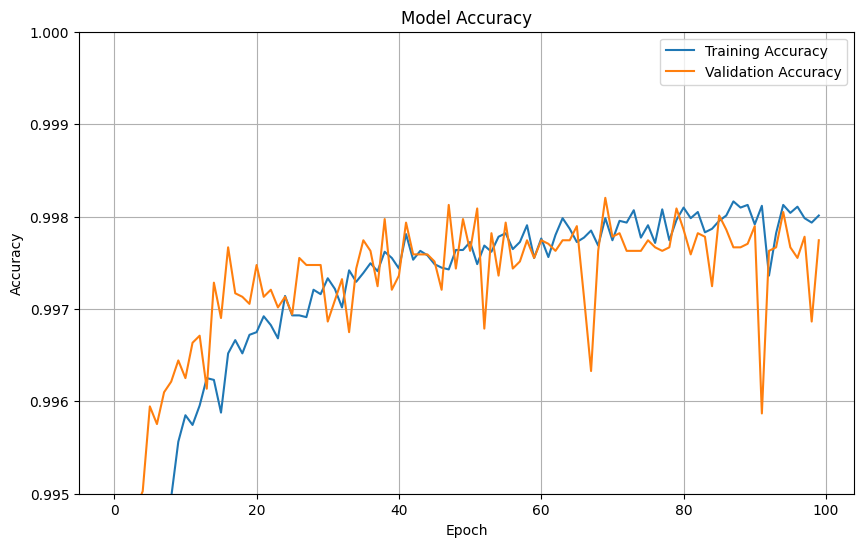

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Limit y-axis to 99% - 100%
plt.ylim(0.995, 1.00)

plt.legend()
plt.grid(True)
plt.show()

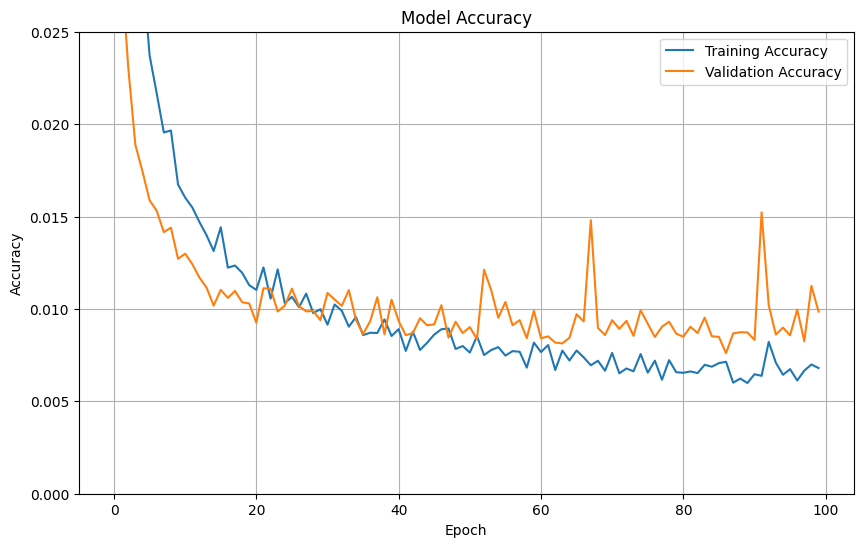

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.ylim(0.0, 0.025)

plt.legend()
plt.grid(True)
plt.show()

Predicted Class Index : 3
Predicted Class Name  : DoS Hulk
Confidence            : 100.0 %


PermutationExplainer explainer: 2it [00:17, 17.79s/it]                                                                 



Generating SHAP Waterfall Plot...



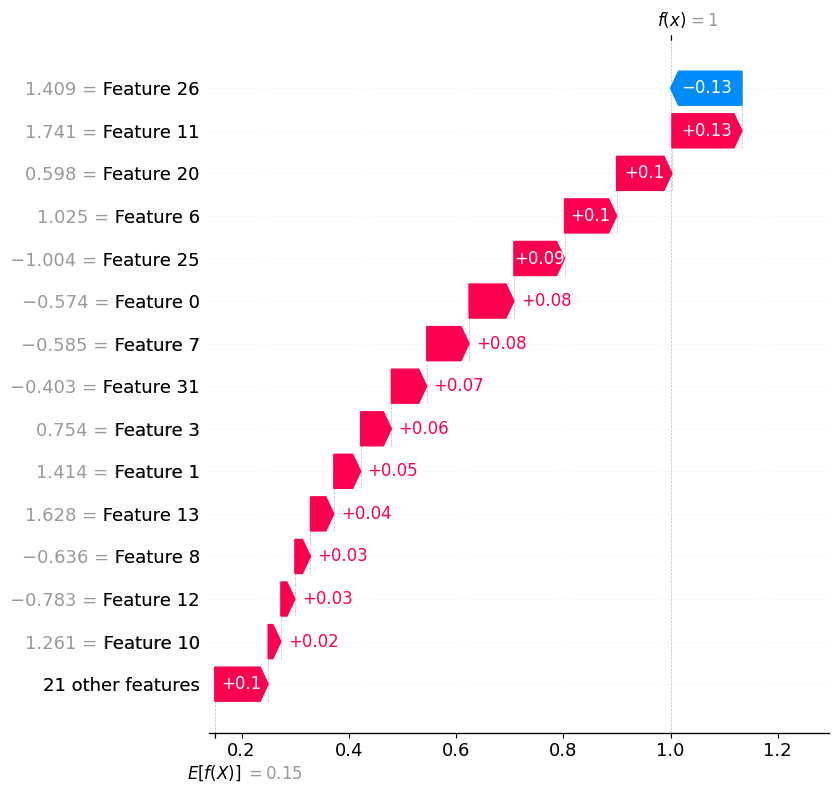


Top Important Features

                        Feature  Feature Value  SHAP Value    Impact
26               ACK Flag Count       1.408794   -0.133172  0.133172
11                 Flow IAT Std       1.740893    0.130545  0.130545
20            Fwd Header Length       0.598378    0.103169  0.103169
6         Bwd Packet Length Max       1.025229    0.097121  0.097121
25               PSH Flag Count      -1.004263    0.094417  0.094417
0              Destination Port      -0.574028    0.083646  0.083646
7         Bwd Packet Length Min      -0.585204    0.078946  0.078946
31             act_data_pkt_fwd      -0.403335    0.065993  0.065993
3   Total Length of Fwd Packets       0.753648    0.057149  0.057149
1                 Flow Duration       1.413857    0.050110  0.050110


WHY DID THE MODEL PREDICT THIS ATTACK?
• ACK Flag Count = 1.4088 decreased the probability of the predicted attack (Contribution = -0.1332)
• Flow IAT Std = 1.7409 increased the probability of the predicted attack 

In [34]:
import shap

# Selecting a random sample from the testing set
sample_index = 3

X_sample = X_test[sample_index:sample_index+1]

# Making the prediction through ANN model
prediction = model.predict(X_sample, verbose=0)

predicted_class = np.argmax(prediction)
confidence = prediction[0][predicted_class]

print("="*60)
print("Predicted Class Index :", predicted_class)
print("Predicted Class Name  :", encoder.inverse_transform([predicted_class])[0])
print("Confidence            :", round(confidence*100,2),"%")
print("="*60)

# Creating a SHAP Explainer
explainer = shap.Explainer(model, X_train[:100])

# Taking one sample for the explaination
shap_values = explainer(X_sample)

# SHAP Waterfall plot
print("\nGenerating SHAP Waterfall Plot...\n")

shap.plots.waterfall(
    shap_values[0, :, predicted_class],
    max_display=15
)

plt.show()

# Creating SHAP values
feature_shap = shap_values.values[0, :, predicted_class]


feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature Value": X_sample[0],
    "SHAP Value": feature_shap
})

feature_df["Impact"] = feature_df["SHAP Value"].abs()

feature_df = feature_df.sort_values(
    by="Impact",
    ascending=False
)

print("\nTop Important Features\n")
print(feature_df.head(10))

# Explanation part of the project
print("\n")
print("="*70)
print("WHY DID THE MODEL PREDICT THIS ATTACK?")
print("="*70)

for _, row in feature_df.head(10).iterrows():

    feature = row["Feature"]
    value = row["Feature Value"]
    shap_value = row["SHAP Value"]

    if shap_value > 0:
        print(f"• {feature} = {value:.4f} increased the probability of the predicted attack "
              f"(Contribution = +{shap_value:.4f})")

    else:
        print(f"• {feature} = {value:.4f} decreased the probability of the predicted attack "
              f"(Contribution = {shap_value:.4f})")

print("="*70)

# Creating final summary part
top_positive = feature_df[feature_df["SHAP Value"] > 0].head(3)["Feature"].tolist()
top_negative = feature_df[feature_df["SHAP Value"] < 0].head(3)["Feature"].tolist()

print("\nSUMMARY")
print("-"*70)

print(f"The ANN classified this network flow as "
      f"{encoder.inverse_transform([predicted_class])[0]} "
      f"with {confidence*100:.2f}% confidence.\n")

if len(top_positive):
    print("Main features supporting the prediction:")
    for feature in top_positive:
        print(f"   ✓ {feature}")

print()

if len(top_negative):
    print("Features reducing confidence:")
    for feature in top_negative:
        print(f"   • {feature}")

In [35]:
import os
import joblib
import shap

os.makedirs("models", exist_ok=True)

model.save("models/ann_model.keras")

joblib.dump(scaler, "models/scaler.pkl")

joblib.dump(encoder, "models/label_encoder.pkl")

joblib.dump(iqr_bounds, "models/iqr_bounds.pkl")

joblib.dump(feature_names, "models/feature_names.pkl")

joblib.dump(X_train[:50], "models/shap_background.pkl")

print("Everything Saved Successfully")

Everything Saved Successfully
